In [ ]:
# Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
# Install dependencies
!pip -q install -U transformers datasets accelerate peft trl bitsandbytes evaluate matplotlib pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 129.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 53.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not cur

## 1. Configuration

In [ ]:
from pathlib import Path

# ----------------------------
# Paths
# ----------------------------
DATASET_PATH = "/content/drive/MyDrive/Speciale/2. Data cleaning/run2/oss_instruct/oss_instruct_cleaned.jsonl"
OUTPUT_DIR = "/content/drive/MyDrive/Speciale/3. Model training/oss_instruct/out_1"

# ----------------------------
# Dataset format
# ----------------------------
DATA_FORMAT = "jsonl"
INSTRUCTION_COL = "instruction"
INPUT_COL = "input"
OUTPUT_COL = "response"
TEXT_COL = None

# ----------------------------
# Split settings
# ----------------------------
VALIDATION_SIZE = 0.2
RANDOM_SEED = 200

# ----------------------------
# Model
# ----------------------------
MODEL_NAME = "Qwen/Qwen2.5-Coder-3B-Instruct"
MAX_SEQ_LENGTH = 1024

# ----------------------------
# LoRA
# ----------------------------
USE_4BIT = True
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"]

# ----------------------------
# Training arguments
# ----------------------------
NUM_TRAIN_EPOCHS = 1
LEARNING_RATE = 2e-4
PER_DEVICE_TRAIN_BATCH_SIZE = 4
PER_DEVICE_EVAL_BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 2
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.03
LOGGING_STEPS = 10
EVAL_STRATEGY = "steps"
EVAL_STEPS = 50
SAVE_STRATEGY = "steps"
SAVE_STEPS = 50
SAVE_TOTAL_LIMIT = 2
BF16 = True
GRADIENT_CHECKPOINTING = True
REPORT_TO = "none"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


## 2. Load the dataset from Google Drive

In [ ]:
import json
import pandas as pd
from datasets import load_dataset, load_from_disk, Dataset, DatasetDict


raw_ds = load_dataset("json", data_files=DATASET_PATH)
raw_ds

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'response', '_row_id', 'syntax_valid', 'exec_valid', 'exec_error', 'prompt_norm', 'response_norm', 'prompt_exact_match', 'entry_point_exact_match', 'solution_exact_match', 'max_prompt_similarity', 'max_code_similarity', 'leakage_flag'],
        num_rows: 19993
    })
})

## 3. Build a train/validation split

In [ ]:
from datasets import DatasetDict

# Create train/validation split from the single imported dataset
sampled_ds = raw_ds["train"].shuffle(seed=RANDOM_SEED).select(range(min(14000, len(raw_ds["train"]))))

split_ds = sampled_ds.train_test_split(
    test_size=VALIDATION_SIZE,
    seed=RANDOM_SEED,
    shuffle=True
)

ds = DatasetDict({
    "train": split_ds["train"],
    "validation": split_ds["test"]
})

print(ds)
print("Train size:", len(ds["train"]))
print("Validation size:", len(ds["validation"]))


DatasetDict({
    train: Dataset({
        features: ['instruction', 'response', '_row_id', 'syntax_valid', 'exec_valid', 'exec_error', 'prompt_norm', 'response_norm', 'prompt_exact_match', 'entry_point_exact_match', 'solution_exact_match', 'max_prompt_similarity', 'max_code_similarity', 'leakage_flag'],
        num_rows: 11200
    })
    validation: Dataset({
        features: ['instruction', 'response', '_row_id', 'syntax_valid', 'exec_valid', 'exec_error', 'prompt_norm', 'response_norm', 'prompt_exact_match', 'entry_point_exact_match', 'solution_exact_match', 'max_prompt_similarity', 'max_code_similarity', 'leakage_flag'],
        num_rows: 2800
    })
})
Train size: 11200
Validation size: 2800


## 4. Convert rows into model training text


In [ ]:
def format_example(example):
    if TEXT_COL is not None:
        return {"text": example[TEXT_COL]}

    instruction = str(example[INSTRUCTION_COL]).strip()
    response = str(example[OUTPUT_COL]).strip()

    input_text = ""
    if INPUT_COL is not None and INPUT_COL in example and example[INPUT_COL] is not None:
        input_text = str(example[INPUT_COL]).strip()

    if input_text:
        text = f"""### Instruction:
{instruction}

### Input:
{input_text}

### Response:
{response}"""
    else:
        text = f"""### Instruction:
{instruction}

### Response:
{response}"""

    return {"text": text}

ds = ds.map(format_example)
ds["train"].select(range(min(3, len(ds["train"])))).to_pandas()[["text"]]

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2800 [00:00<?, ? examples/s]

,text
0,### Instruction:\nImplement a FileProcessor cl...
1,### Instruction:\nWrite a function that takes ...
2,### Instruction:\nImplement a function that ta...


## 5. Load tokenizer and model

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = None
if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16 if BF16 else torch.float16
    )

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

if USE_4BIT:
    model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=TARGET_MODULES
)

model = get_peft_model(model, peft_config)

if GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()
    model.config.use_cache = False

model.print_trainable_parameters()

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


## 6. Tokenize dataset

In [ ]:
from transformers import TrainingArguments
from trl import SFTTrainer

# Tokenize the dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_SEQ_LENGTH)

tokenized_ds = ds.map(tokenize_function, batched=True)

# Calculate warmup steps
total_training_steps = (len(tokenized_ds["train"]) // PER_DEVICE_TRAIN_BATCH_SIZE // GRADIENT_ACCUMULATION_STEPS) * NUM_TRAIN_EPOCHS
warmup_steps = int(total_training_steps * WARMUP_RATIO)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=warmup_steps,
    logging_steps=LOGGING_STEPS,
    eval_strategy=EVAL_STRATEGY,
    eval_steps=EVAL_STEPS,
    save_strategy=SAVE_STRATEGY,
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    bf16=BF16,
    gradient_checkpointing=GRADIENT_CHECKPOINTING,
    report_to=REPORT_TO,
    logging_dir=f"{OUTPUT_DIR}/logs",
    load_best_model_at_end=True if EVAL_STRATEGY in ["steps", "epoch"] else False,
    metric_for_best_model="eval_loss",
    greater_is_better=False
)

trainer = SFTTrainer(
    model=model,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    args=training_args
)

Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2800 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 7. Train

In [ ]:
train_result = trainer.train()
train_result

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
50,0.740368,0.788708
100,0.708833,0.774612
150,0.757382,0.767071
200,0.772607,0.762158
250,0.709117,0.759615
300,0.714585,0.756394
350,0.729949,0.755209
400,0.755070,0.752396
450,0.715360,0.750532
500,0.732919,0.749486


TrainOutput(global_step=1400, training_loss=0.7342260200636728, metrics={'train_runtime': 6460.531, 'train_samples_per_second': 1.734, 'train_steps_per_second': 0.217, 'total_flos': 5.583086307370598e+16, 'train_loss': 0.7342260200636728})

## 8. Evaluate and save metrics

In [ ]:
# eval_metrics = trainer.evaluate()
# print(eval_metrics)

trainer.save_model(f"{OUTPUT_DIR}/final_adapter")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/final_adapter")

# with open(f"{OUTPUT_DIR}/eval_metrics.json", "w") as f:
#     json.dump(eval_metrics, f, indent=2)

# print("Saved model adapter and metrics to:", OUTPUT_DIR)

('/content/drive/MyDrive/Speciale/3. Model training/oss_instruct/out_1/final_adapter/tokenizer_config.json',
 '/content/drive/MyDrive/Speciale/3. Model training/oss_instruct/out_1/final_adapter/chat_template.jinja',
 '/content/drive/MyDrive/Speciale/3. Model training/oss_instruct/out_1/final_adapter/tokenizer.json')

## 9. Plot training and validation curves

,loss,grad_norm,learning_rate,entropy,num_tokens,mean_token_accuracy,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,eval_entropy,eval_num_tokens,eval_mean_token_accuracy,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
149,NaN,NaN,NaN,NaN,NaN,NaN,0.892857,1250,0.735578,147.0772,19.038,4.759,0.739213,1899486.0,0.813429,NaN,NaN,NaN,NaN,NaN
150,0.727176,0.365234,2.076583e-05,0.747506,1914116.0,0.813344,0.900000,1260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,0.696784,0.304688,1.929308e-05,0.699391,1931485.0,0.825171,0.907143,1270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,0.695877,0.380859,1.782032e-05,0.706398,1947596.0,0.824584,0.914286,1280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,0.726384,0.390625,1.634757e-05,0.734059,1962652.0,0.818386,0.921429,1290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,0.720877,0.328125,1.487482e-05,0.717512,1976943.0,0.818685,0.928571,1300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155,NaN,NaN,NaN,NaN,NaN,NaN,0.928571,1300,0.735354,146.9605,19.053,4.763,0.736275,1976943.0,0.813622,NaN,NaN,NaN,NaN,NaN
156,0.689207,0.298828,1.340206e-05,0.677502,1993249.0,0.824224,0.935714,1310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
157,0.753074,0.314453,1.192931e-05,0.762852,2008714.0,0.804598,0.942857,1320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,0.729828,0.414062,1.045655e-05,0.745052,2024339.0,0.815179,0.950000,1330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


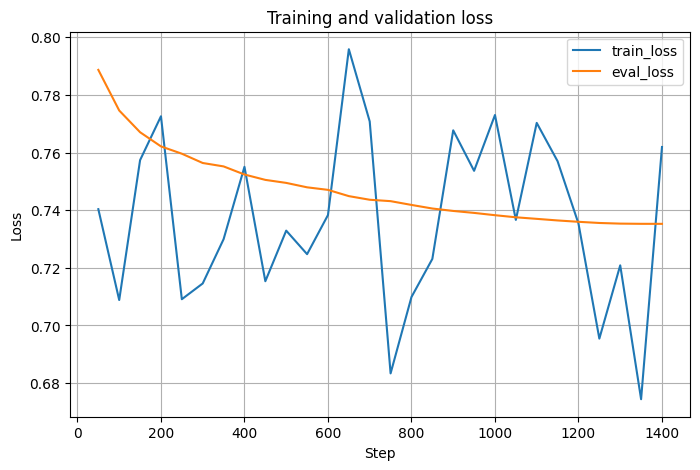

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

log_history = pd.DataFrame(trainer.state.log_history)
display(log_history.tail(20))

plt.figure(figsize=(8, 5))
train_logs = log_history[log_history["loss"].notna()].copy() if "loss" in log_history.columns else pd.DataFrame()
eval_logs = log_history[log_history["eval_loss"].notna()].copy() if "eval_loss" in log_history.columns else pd.DataFrame()

if not train_logs.empty:
    plt.plot(train_logs["step"], train_logs["loss"], label="train_loss")
if not eval_logs.empty:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="eval_loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

## 10. Inspect a few validation examples with generations

In [ ]:
from transformers import GenerationConfig
import random
import torch

def build_inference_prompt(example):
    if TEXT_COL is not None:
        return example["text"]

    instruction = str(example[INSTRUCTION_COL]).strip()
    input_text = ""
    if INPUT_COL is not None and INPUT_COL in example and example[INPUT_COL] is not None:
        input_text = str(example[INPUT_COL]).strip()

    if input_text:
        return f"""### Instruction:
{instruction}

### Input:
{input_text}

### Response:
"""
    return f"""### Instruction:
{instruction}

### Response:
"""

sample_indices = random.sample(range(len(ds["validation"])), k=min(3, len(ds["validation"])))
samples = ds["validation"].select(sample_indices)

for i, ex in enumerate(samples):
    prompt = build_inference_prompt(ex)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.pad_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    print("=" * 80)
    print(f"Example {i+1}")
    print("- Prompt -")
    print(prompt[:1200])
    print("- Reference output -")
    print(str(ex[OUTPUT_COL])[:1200] if OUTPUT_COL in ex else "N/A")
    print("- Model generation -")
    print(decoded[:2000])
    print()

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Example 1
- Prompt -
### Instruction:
Write a function to remove the 'archived' column from the 'LoadTbl' database table using Alembic's batch operations.

### Response:

- Reference output -
def downgrade():
    from alembic import op
    import sqlalchemy as sa

    # Define the downgrade operation using op.drop_column()
    with op.batch_alter_table('LoadTbl') as batch_op:
        batch_op.drop_column('archived')
- Model generation -
### Instruction:
Write a function to remove the 'archived' column from the 'LoadTbl' database table using Alembic's batch operations.

### Response:
def upgrade():
    with op.batch_alter_table('LoadTbl') as batch_op:
        batch_op.drop_column('archived')  # Remove the 'archived' column from the 'LoadTbl' table

def downgrade():
    with op.batch_alter_table('LoadTbl') as batch_op:
        batch_op.add_column(sa.Column('archived', sa.Boolean(), nullable=True))  # Add the 'archived' column back to the 'LoadTbl' table
        batch_op.alter_column('arc

## 12. Optional: save train/validation splits used in this run

This is useful for experiment reproducibility.

In [ ]:
ds.save_to_disk(f"{OUTPUT_DIR}/dataset_splits")
print("Saved dataset splits to:", f"{OUTPUT_DIR}/dataset_splits")

Saving the dataset (0/1 shards):   0%|          | 0/11200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2800 [00:00<?, ? examples/s]

Saved dataset splits to: /content/drive/MyDrive/Speciale/3. Model training/oss_instruct/out_1/dataset_splits


In [ ]:
#Push to huggingface
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HF_TOKEN"))

repo_name = "oss_isntruct"

trainer.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:4838: UserWarning: It seems that you are about to commit a data file (dataset_splits/train/data-00000-of-00001.arrow) to a model repository. You are sure this is intended? If you are trying to upload a dataset, please set `repo_type='dataset'` or `--repo-type=dataset` in a CLI.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:4838: UserWarning: It seems that you are about to commit a data file (dataset_splits/validation/data-00000-of-00001.arrow) to a model repository. You are sure this is intended? If you are trying to upload a dataset, please set `repo_type='dataset'` or `--repo-type=dataset` in a CLI.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ruct/out_1/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...al_adapter/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

...

  ...t/out_1/training_args.bin:   3%|2         |   150B / 5.78kB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mp8pe5jdm_/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

CommitInfo(commit_url='https://huggingface.co/Luca0867/oss_isntruct/commit/ada805ad096168ac9b496fa691603cdf730a25bc', commit_message='Upload tokenizer', commit_description='', oid='ada805ad096168ac9b496fa691603cdf730a25bc', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Luca0867/oss_isntruct', endpoint='https://huggingface.co', repo_type='model', repo_id='Luca0867/oss_isntruct'), pr_revision=None, pr_num=None)